# PCA Artifact Analysis for `xxx`

This notebook only reads PCA artifacts under `feature_selection/pca/select_pca/`.

Use it in two modes:
- single artifact set: summarize the currently committed PCA results
- paired artifact sets: compare `with_xxx` and `without_xxx` runs side by side

Important limitation:
- the current PCA artifacts store transformed matrices, explained variance tables, PCA component names, and run metadata
- they do not store labels, row ids, predictions, or saved confusion matrices
- because of that, this notebook can compare result metrics across artifact sets, but it cannot reconstruct a new confusion matrix from artifacts alone

If you want the `xxx` comparison to work, keep two PCA artifact snapshots, for example:
- `artifacts_with_xxx/`
- `artifacts_without_xxx/`


In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use('ggplot')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 200)

print('Imports loaded.')


Imports loaded.


In [2]:
from pathlib import Path
import sys

CWD = Path.cwd().resolve()
REPO_ROOT = CWD if (CWD / 'pyproject.toml').exists() else next(
    path for path in [CWD, *CWD.parents] if (path / 'pyproject.toml').exists()
)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from feature_selection.common import resolve_pca_artifact_dir

PCA_DIR = REPO_ROOT / 'feature_selection' / 'pca' / 'select_pca'
DEFAULT_ARTIFACT_DIR = PCA_DIR / 'artifacts'
WITH_XXX_DIR = resolve_pca_artifact_dir(REPO_ROOT, include_xxx=True, use_variant_dirs=True)
WITHOUT_XXX_DIR = resolve_pca_artifact_dir(REPO_ROOT, include_xxx=False, use_variant_dirs=True)

ARTIFACT_GROUPS = {}
if WITH_XXX_DIR.exists():
    ARTIFACT_GROUPS['with_xxx'] = WITH_XXX_DIR
if WITHOUT_XXX_DIR.exists():
    ARTIFACT_GROUPS['without_xxx'] = WITHOUT_XXX_DIR
if not ARTIFACT_GROUPS and DEFAULT_ARTIFACT_DIR.exists():
    ARTIFACT_GROUPS['current'] = DEFAULT_ARTIFACT_DIR

DATASET_FILTER = None
FOCUS_DATASET = None
SAVE_COMPARISON_CSV = True

for group_name, artifact_dir in ARTIFACT_GROUPS.items():
    print(f'{group_name}: {artifact_dir} | exists={artifact_dir.exists()}')


with_xxx: /Users/fidjestol/Documents/GitHub/Speech-Emotion-Recognition/feature_selection/pca/select_pca/artifacts_with_xxx | exists=True
without_xxx: /Users/fidjestol/Documents/GitHub/Speech-Emotion-Recognition/feature_selection/pca/select_pca/artifacts_without_xxx | exists=True


In [3]:
def load_group_summary(group_name: str, artifact_dir: Path) -> pd.DataFrame:
    rows = []
    for meta_path in sorted(artifact_dir.glob('*_run_metadata.json')):
        meta = json.loads(meta_path.read_text(encoding='utf-8'))
        rows.append({
            'group': group_name,
            'dataset_key': meta['dataset_key'],
            'rows_used': meta.get('rows_used'),
            'original_features': meta.get('original_features'),
            'pca_components': meta.get('pca_components_effective'),
            'variance_kept': meta.get('pca_explained_variance_total'),
            'best_baseline_model': meta.get('best_baseline_model'),
            'best_pca_model': meta.get('best_pca_model'),
            'baseline_accuracy': meta.get('baseline_accuracy'),
            'baseline_f1_weighted': meta.get('baseline_f1_weighted'),
            'pca_accuracy': meta.get('pca_accuracy'),
            'pca_f1_weighted': meta.get('pca_f1_weighted'),
            'source_path': meta.get('source_path'),
        })

    df = pd.DataFrame(rows)
    if df.empty:
        return df

    df['accuracy_delta'] = df['pca_accuracy'] - df['baseline_accuracy']
    df['f1_weighted_delta'] = df['pca_f1_weighted'] - df['baseline_f1_weighted']
    if DATASET_FILTER is not None:
        df = df[df['dataset_key'].isin(DATASET_FILTER)].copy()
    return df.sort_values(['group', 'pca_f1_weighted'], ascending=[True, False], ignore_index=True)


def load_model_delta_table(group_name: str, artifact_dir: Path) -> pd.DataFrame:
    rows = []
    for meta_path in sorted(artifact_dir.glob('*_run_metadata.json')):
        meta = json.loads(meta_path.read_text(encoding='utf-8'))
        for row in meta.get('model_metric_deltas', []):
            rows.append({
                'group': group_name,
                'dataset_key': meta['dataset_key'],
                **row,
            })

    df = pd.DataFrame(rows)
    if df.empty:
        return df
    if DATASET_FILTER is not None:
        df = df[df['dataset_key'].isin(DATASET_FILTER)].copy()
    return df


def load_variance_table(dataset_key: str, artifact_dir: Path) -> pd.DataFrame:
    path = artifact_dir / f'{dataset_key}_pca_explained_variance.csv'
    if not path.exists():
        raise FileNotFoundError(path)
    return pd.read_csv(path)


def build_pairwise_comparison(summary_df: pd.DataFrame, left_group: str, right_group: str) -> pd.DataFrame:
    left_df = summary_df[summary_df['group'] == left_group].copy()
    right_df = summary_df[summary_df['group'] == right_group].copy()

    merged = left_df.merge(
        right_df,
        on='dataset_key',
        suffixes=(f'|{left_group}', f'|{right_group}')
    )

    merged[f'pca_f1_change_{right_group}_minus_{left_group}'] = (
        merged[f'pca_f1_weighted|{right_group}'] - merged[f'pca_f1_weighted|{left_group}']
    )
    merged[f'baseline_f1_change_{right_group}_minus_{left_group}'] = (
        merged[f'baseline_f1_weighted|{right_group}'] - merged[f'baseline_f1_weighted|{left_group}']
    )
    merged[f'pca_delta_change_{right_group}_minus_{left_group}'] = (
        merged[f'f1_weighted_delta|{right_group}'] - merged[f'f1_weighted_delta|{left_group}']
    )
    return merged.sort_values(f'pca_f1_change_{right_group}_minus_{left_group}', ascending=False, ignore_index=True)


## Artifact Summary

This section summarizes each available PCA artifact group independently.


In [4]:
summary_frames = []
delta_frames = []

for group_name, artifact_dir in ARTIFACT_GROUPS.items():
    if artifact_dir.exists():
        summary_frames.append(load_group_summary(group_name, artifact_dir))
        delta_frames.append(load_model_delta_table(group_name, artifact_dir))

summary_df = pd.concat(summary_frames, ignore_index=True) if summary_frames else pd.DataFrame()
model_delta_df = pd.concat(delta_frames, ignore_index=True) if delta_frames else pd.DataFrame()

summary_df


,group,dataset_key,rows_used,original_features,pca_components,variance_kept,best_baseline_model,best_pca_model,baseline_accuracy,baseline_f1_weighted,pca_accuracy,pca_f1_weighted,source_path,accuracy_delta,f1_weighted_delta
0,with_xxx,ssl_wav2vec,9887,1539,300,0.909444,logreg,logreg,0.345298,0.341695,0.425177,0.412720,/Users/fidjestol/Documents/GitHub/Speech-Emoti...,0.079879,0.071024
1,with_xxx,bert,9887,768,300,0.943603,random_forest,random_forest,0.416077,0.412480,0.403943,0.397082,/Users/fidjestol/Documents/GitHub/Speech-Emoti...,-0.012133,-0.015398
2,with_xxx,ssl_hubert,9887,1539,300,0.933246,logreg,logreg,0.349848,0.350061,0.396360,0.385936,/Users/fidjestol/Documents/GitHub/Speech-Emoti...,0.046512,0.035875
3,with_xxx,mfcc_raw,9887,1150,300,0.962062,random_forest,logreg,0.395854,0.376624,0.351871,0.336210,/Users/fidjestol/Documents/GitHub/Speech-Emoti...,-0.043984,-0.040414
4,with_xxx,tfidf,216,10480,172,1.000000,linear_svc,linear_svc,0.363636,0.343927,0.295455,0.326569,/Users/fidjestol/Documents/GitHub/Speech-Emoti...,-0.068182,-0.017358
5,with_xxx,prosody_energy,9887,8,8,1.000000,random_forest,random_forest,0.265420,0.252211,0.289181,0.269624,/Users/fidjestol/Documents/GitHub/Speech-Emoti...,0.023761,0.017413
6,without_xxx,ssl_wav2vec,7380,1539,300,0.912031,logreg,linear_svc,0.475610,0.476139,0.539295,0.535111,/Users/fidjestol/Documents/GitHub/Speech-Emoti...,0.063686,0.058972
7,without_xxx,ssl_hubert,7380,1539,300,0.934663,logreg,linear_svc,0.471545,0.471608,0.509485,0.501104,/Users/fidjestol/Documents/GitHub/Speech-Emoti...,0.037940,0.029496
8,without_xxx,bert,7380,768,300,0.943393,random_forest,random_forest,0.527778,0.519458,0.494580,0.488138,/Users/fidjestol/Documents/GitHub/Speech-Emoti...,-0.033198,-0.031321
9,without_xxx,mfcc_raw,7380,1150,300,0.963268,random_forest,linear_svc,0.487805,0.465665,0.456640,0.446967,/Users/fidjestol/Documents/GitHub/Speech-Emoti...,-0.031165,-0.018698


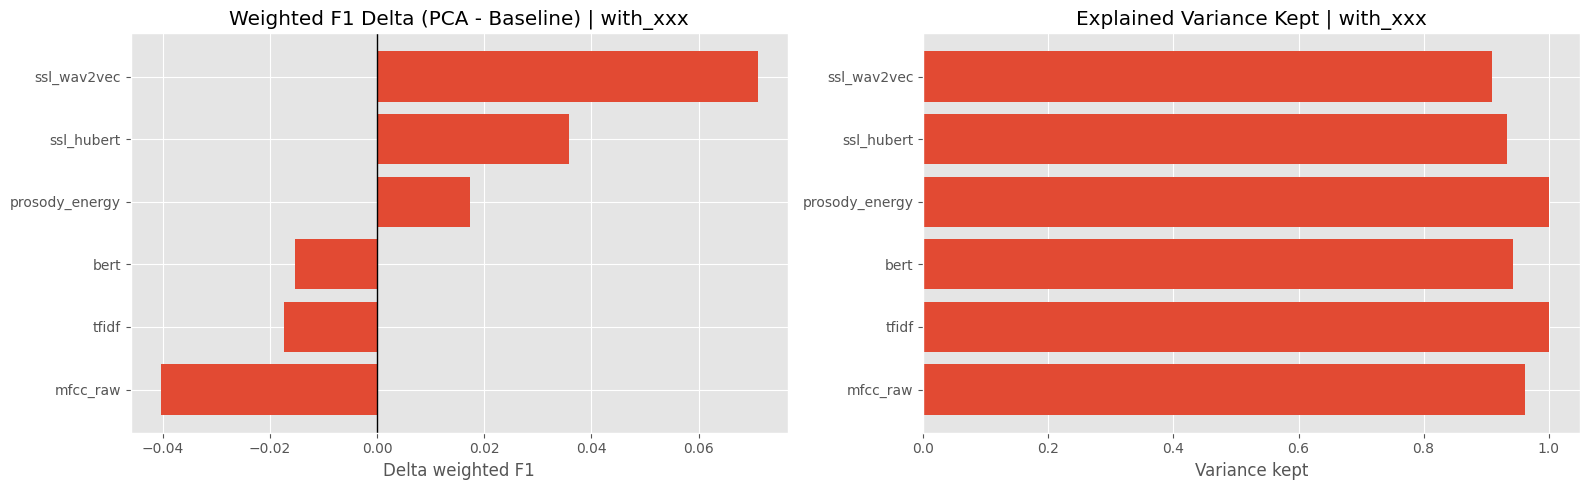

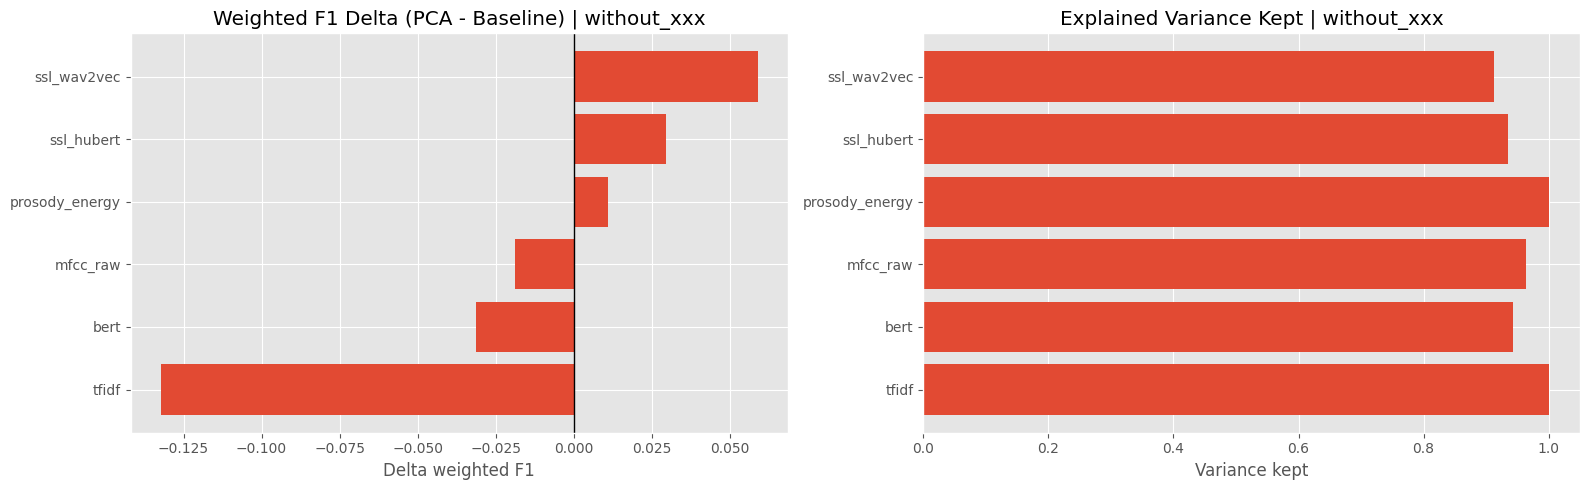

In [5]:
if not summary_df.empty:
    for group_name in summary_df['group'].unique():
        group_df = summary_df[summary_df['group'] == group_name].copy().sort_values('f1_weighted_delta', ascending=True)
        fig, axes = plt.subplots(1, 2, figsize=(16, 5))

        axes[0].barh(group_df['dataset_key'], group_df['f1_weighted_delta'])
        axes[0].axvline(0.0, color='black', linewidth=1)
        axes[0].set_title(f'Weighted F1 Delta (PCA - Baseline) | {group_name}')
        axes[0].set_xlabel('Delta weighted F1')

        axes[1].barh(group_df['dataset_key'], group_df['variance_kept'])
        axes[1].set_title(f'Explained Variance Kept | {group_name}')
        axes[1].set_xlabel('Variance kept')
        axes[1].set_xlim(0, 1.05)

        plt.tight_layout()
        plt.show()
else:
    print('No PCA artifact metadata found.')


In [6]:
if not model_delta_df.empty:
    best_per_dataset = model_delta_df.sort_values('f1_weighted_selected', ascending=False).groupby(['group', 'dataset_key'], as_index=False).first()
    display(best_per_dataset[['group', 'dataset_key', 'model', 'f1_weighted_baseline', 'f1_weighted_selected', 'f1_weighted_delta', 'accuracy_delta']])
else:
    print('No per-model delta rows found.')


,group,dataset_key,model,f1_weighted_baseline,f1_weighted_selected,f1_weighted_delta,accuracy_delta
0,with_xxx,bert,random_forest,0.412480,0.397082,-0.015398,-0.012133
1,with_xxx,mfcc_raw,logreg,0.331343,0.336210,0.004868,0.014661
2,with_xxx,prosody_energy,random_forest,0.252211,0.269624,0.017413,0.023761
3,with_xxx,ssl_hubert,logreg,0.350061,0.385936,0.035875,0.046512
4,with_xxx,ssl_wav2vec,logreg,0.341695,0.412720,0.071024,0.079879
5,with_xxx,tfidf,linear_svc,0.343927,0.326569,-0.017358,-0.068182
6,without_xxx,bert,random_forest,0.519458,0.488138,-0.031321,-0.033198
7,without_xxx,mfcc_raw,linear_svc,0.425307,0.446967,0.021660,0.027100
8,without_xxx,prosody_energy,random_forest,0.321346,0.332493,0.011146,0.014228
9,without_xxx,ssl_hubert,linear_svc,0.447675,0.501104,0.053428,0.062331


Variance curve preview for ssl_wav2vec | group=with_xxx


,component,explained_variance_ratio,cumulative_explained_variance
0,pca_0000,0.460485,0.460485
1,pca_0001,0.066351,0.526836
2,pca_0002,0.036525,0.563361
3,pca_0003,0.026224,0.589585
4,pca_0004,0.016527,0.606112
5,pca_0005,0.013703,0.619814
6,pca_0006,0.010492,0.630306
7,pca_0007,0.009913,0.640220
8,pca_0008,0.008831,0.649051
9,pca_0009,0.008029,0.657080


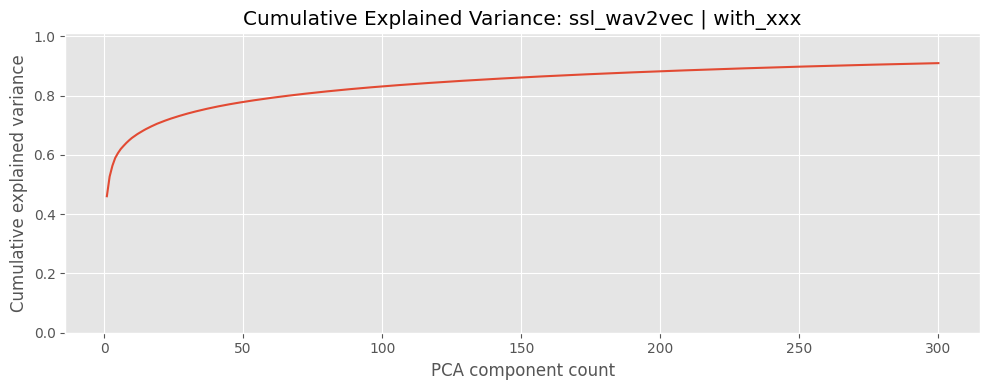

Variance curve preview for ssl_wav2vec | group=without_xxx


,component,explained_variance_ratio,cumulative_explained_variance
0,pca_0000,0.460758,0.460758
1,pca_0001,0.066754,0.527511
2,pca_0002,0.038233,0.565745
3,pca_0003,0.025676,0.591421
4,pca_0004,0.016752,0.608173
5,pca_0005,0.013607,0.621780
6,pca_0006,0.010594,0.632375
7,pca_0007,0.009896,0.642270
8,pca_0008,0.008737,0.651007
9,pca_0009,0.008018,0.659025


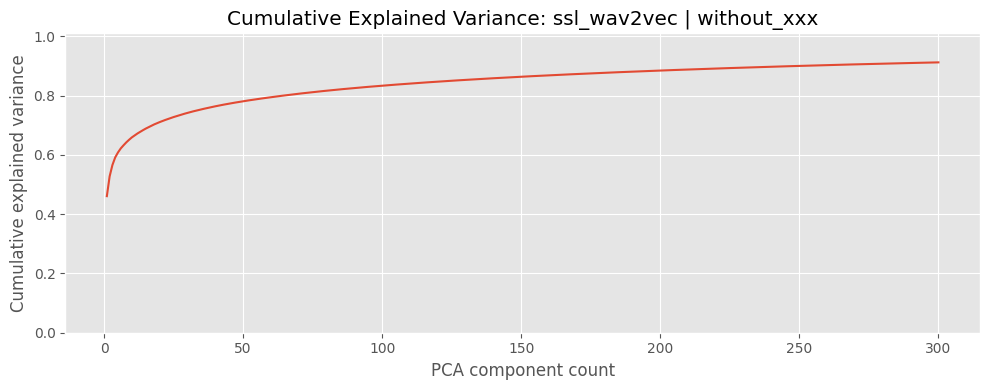

In [7]:
if not summary_df.empty:
    selected_dataset = FOCUS_DATASET or summary_df.iloc[0]['dataset_key']
    available_groups = summary_df[summary_df['dataset_key'] == selected_dataset]['group'].tolist()

    for group_name in available_groups:
        variance_df = load_variance_table(selected_dataset, ARTIFACT_GROUPS[group_name])
        print(f'Variance curve preview for {selected_dataset} | group={group_name}')
        display(variance_df.head(15))

        fig, ax = plt.subplots(figsize=(10, 4))
        ax.plot(range(1, len(variance_df) + 1), variance_df['cumulative_explained_variance'])
        ax.set_title(f'Cumulative Explained Variance: {selected_dataset} | {group_name}')
        ax.set_xlabel('PCA component count')
        ax.set_ylabel('Cumulative explained variance')
        ax.set_ylim(0, 1.01)
        plt.tight_layout()
        plt.show()


## `with_xxx` vs `without_xxx`

This section compares two PCA artifact groups directly.

Expected setup:
- `with_xxx`: PCA artifacts produced from a run where `xxx` was kept
- `without_xxx`: PCA artifacts produced from a run where `xxx` was excluded

If those two groups are not configured, the notebook cannot show the actual with/without difference yet.


,dataset_key,rows_used|with_xxx,rows_used|without_xxx,baseline_f1_weighted|with_xxx,baseline_f1_weighted|without_xxx,pca_f1_weighted|with_xxx,pca_f1_weighted|without_xxx,f1_weighted_delta|with_xxx,f1_weighted_delta|without_xxx,pca_f1_change_without_xxx_minus_with_xxx,pca_delta_change_without_xxx_minus_with_xxx
0,ssl_wav2vec,9887,7380,0.341695,0.476139,0.412720,0.535111,0.071024,0.058972,0.122391,-0.012052
1,ssl_hubert,9887,7380,0.350061,0.471608,0.385936,0.501104,0.035875,0.029496,0.115168,-0.006378
2,mfcc_raw,9887,7380,0.376624,0.465665,0.336210,0.446967,-0.040414,-0.018698,0.110757,0.021716
3,bert,9887,7380,0.412480,0.519458,0.397082,0.488138,-0.015398,-0.031321,0.091055,-0.015923
4,prosody_energy,9887,7380,0.252211,0.321346,0.269624,0.332493,0.017413,0.011146,0.062869,-0.006267
5,tfidf,216,172,0.343927,0.422690,0.326569,0.290321,-0.017358,-0.132369,-0.036248,-0.115011


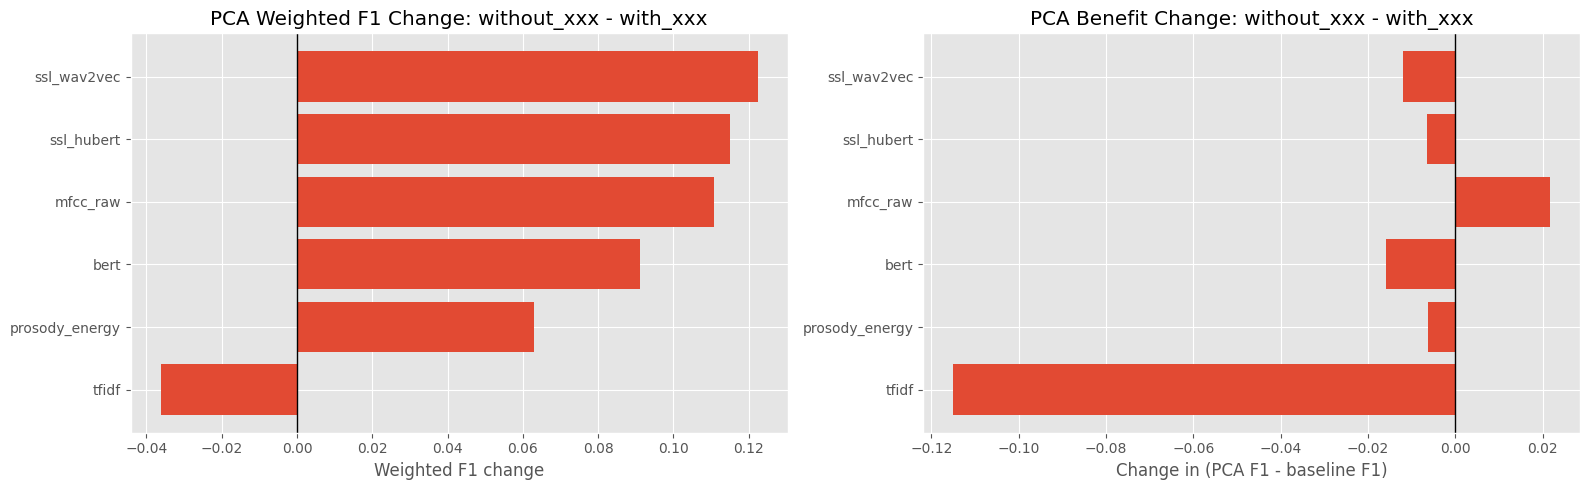

Saved comparison CSV: /Users/fidjestol/Documents/GitHub/Speech-Emotion-Recognition/feature_selection/pca/select_pca/artifacts/pca_xxx_artifact_comparison.csv


In [8]:
required_groups = {'with_xxx', 'without_xxx'}
available_groups = set(summary_df['group'].unique()) if not summary_df.empty else set()

if not required_groups.issubset(available_groups):
    print('Configured artifact groups do not yet include both `with_xxx` and `without_xxx`.')
    print('Update `ARTIFACT_GROUPS` to point to two saved PCA artifact directories so this comparison can run.')
else:
    xxx_compare_df = build_pairwise_comparison(summary_df, 'with_xxx', 'without_xxx')
    display(xxx_compare_df[[
        'dataset_key',
        'rows_used|with_xxx',
        'rows_used|without_xxx',
        'baseline_f1_weighted|with_xxx',
        'baseline_f1_weighted|without_xxx',
        'pca_f1_weighted|with_xxx',
        'pca_f1_weighted|without_xxx',
        'f1_weighted_delta|with_xxx',
        'f1_weighted_delta|without_xxx',
        'pca_f1_change_without_xxx_minus_with_xxx',
        'pca_delta_change_without_xxx_minus_with_xxx',
    ]])

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    plot_df = xxx_compare_df.sort_values('pca_f1_change_without_xxx_minus_with_xxx', ascending=True)

    axes[0].barh(plot_df['dataset_key'], plot_df['pca_f1_change_without_xxx_minus_with_xxx'])
    axes[0].axvline(0.0, color='black', linewidth=1)
    axes[0].set_title('PCA Weighted F1 Change: without_xxx - with_xxx')
    axes[0].set_xlabel('Weighted F1 change')

    axes[1].barh(plot_df['dataset_key'], plot_df['pca_delta_change_without_xxx_minus_with_xxx'])
    axes[1].axvline(0.0, color='black', linewidth=1)
    axes[1].set_title('PCA Benefit Change: without_xxx - with_xxx')
    axes[1].set_xlabel('Change in (PCA F1 - baseline F1)')

    plt.tight_layout()
    plt.show()

    if SAVE_COMPARISON_CSV:
        out_path = DEFAULT_ARTIFACT_DIR / 'pca_xxx_artifact_comparison.csv'
        xxx_compare_df.to_csv(out_path, index=False)
        print(f'Saved comparison CSV: {out_path}')
